In [1]:
import sys
import os 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random

sys.path.append(os.path.abspath("../"))
from simulators.drossel_schwabl_CA import DrosselSchwablForestFire, DrosselSchwablFFM
import pandas as pd
from collections import Counter

# Simulation of fire spread with the Drossel Schwabl model

In [2]:
def plot_forest(model, step=None):
    cmap = mcolors.ListedColormap(["white", "green", "orange"])
    norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    plt.figure(figsize=(6, 6))
    plt.imshow(model.grid, cmap=cmap, norm=norm)
    plt.axis("off")

    if step is not None:
        plt.title(f"Step {step}")

    plt.show()

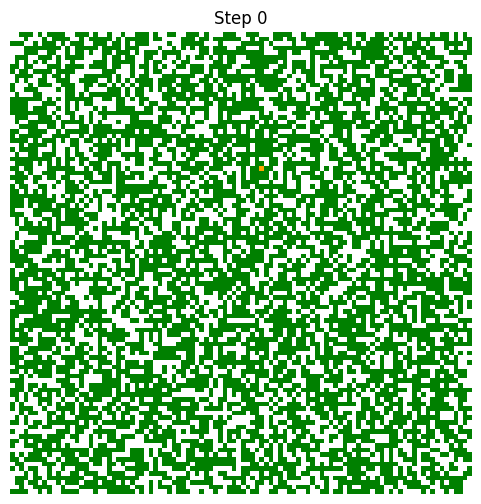

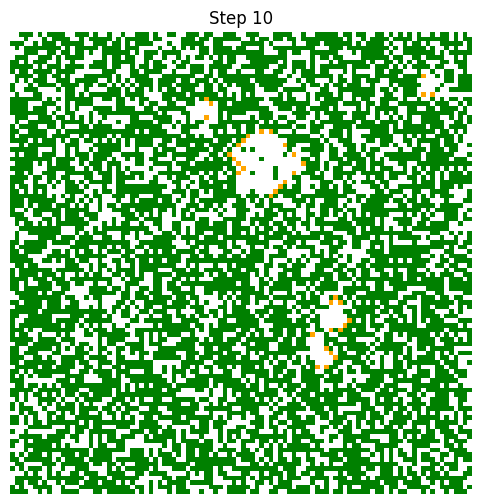

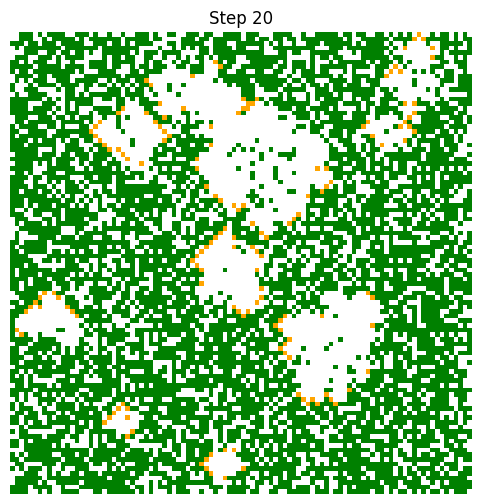

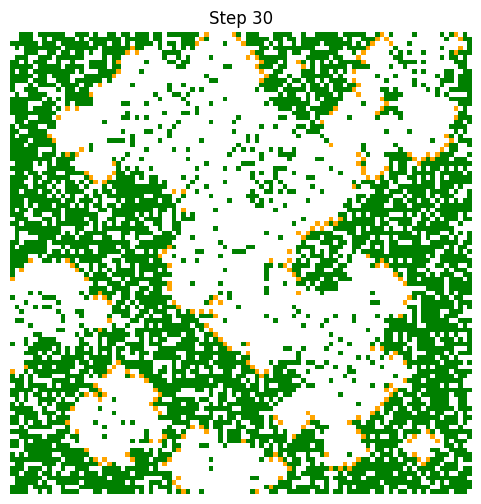

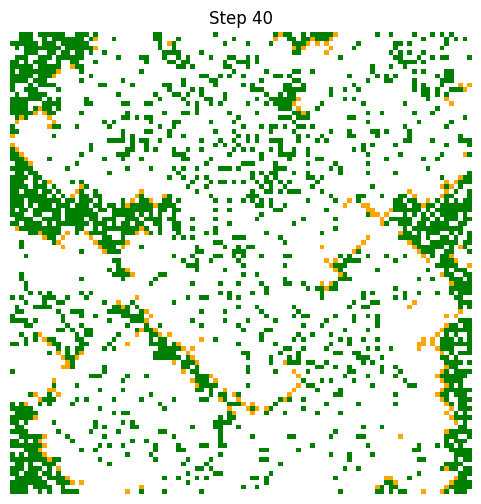

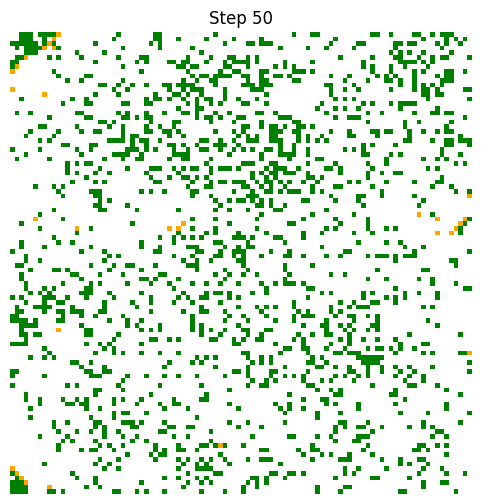

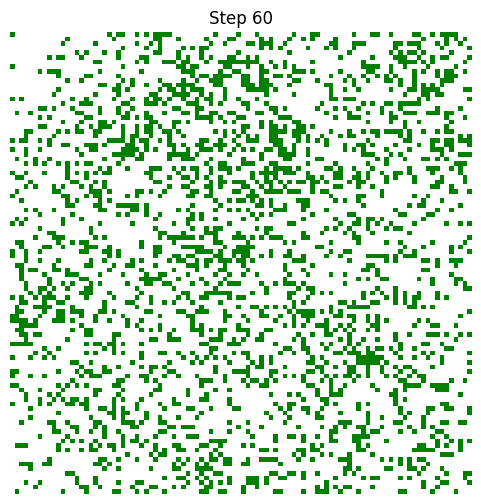

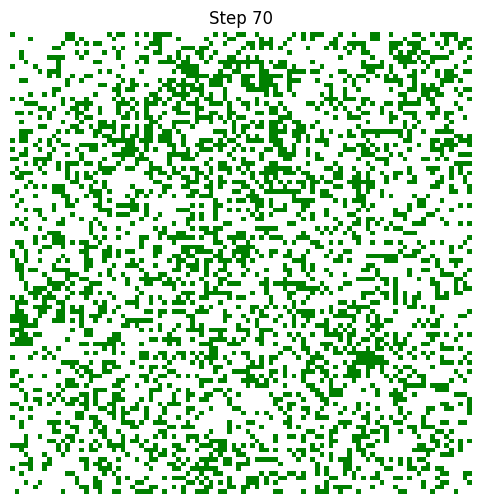

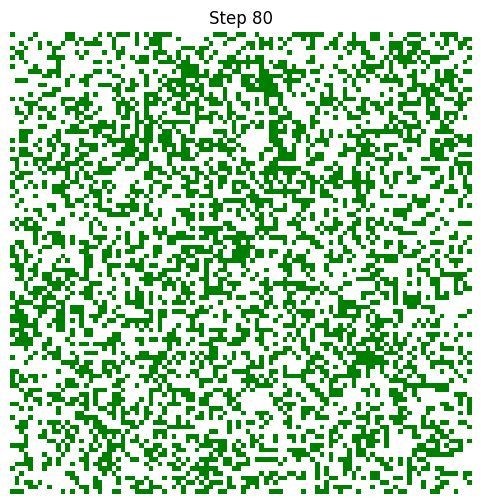

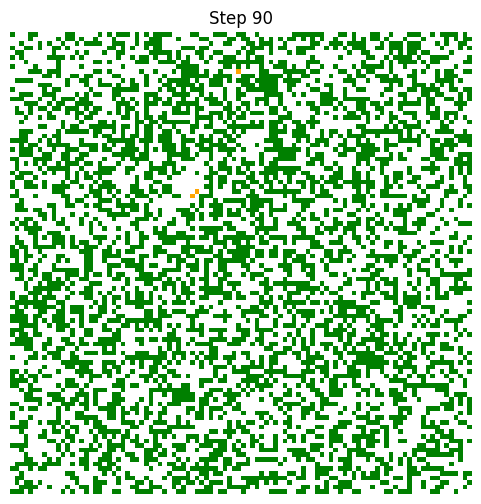

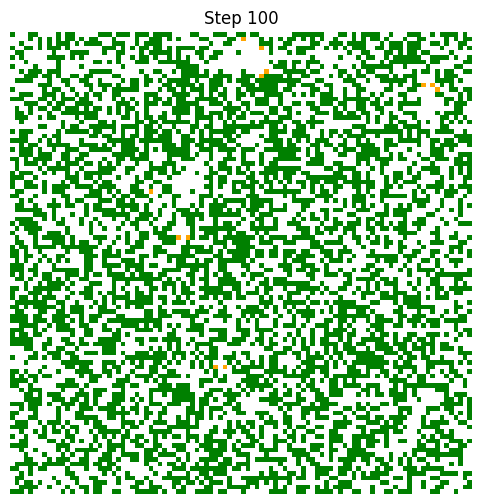

In [3]:
model = DrosselSchwablForestFire(
    width=100,
    height=100,
    p=0.01,          # growth
    f=0.0001,        # lightning
    initial_tree_density=0.6
)

model.ignite_random_tree()

n_steps = 100

for step in range(n_steps + 1):
    if step % 10 == 0:
        plot_forest(model, step)

    model.step()

# Tree density across time

In [4]:
def count_states(model):

    """Count the number of trees, fires, and empty cells in the model."""
    trees = 0
    fires = 0
    empty = 0

    for row in model.grid:
        for cell in row:
            if cell == model.TREE:
                trees += 1
            elif cell == model.FIRE:
                fires += 1
            else:
                empty += 1

    return trees, fires, empty


def simulate_state_counts(model, n_steps=5000):
    """Simulate the model for a given number of steps and count the states at each step."""
    trees_series = []
    fires_series = []
    empty_series = []

    for _ in range(n_steps):
        trees, fires, empty = count_states(model)
        trees_series.append(trees)
        fires_series.append(fires)
        empty_series.append(empty)
        model.step()

    return trees_series, fires_series, empty_series




Simulaton over for theta = 5
Simulaton over for theta = 10
Simulaton over for theta = 20
Simulaton over for theta = 50


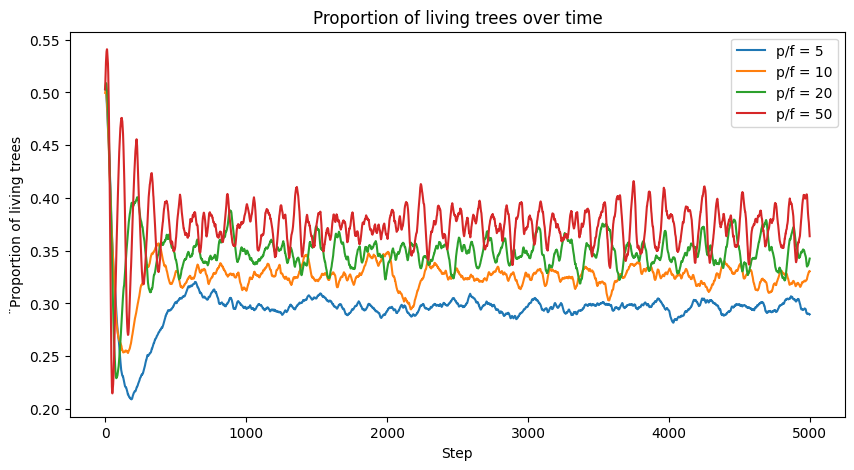

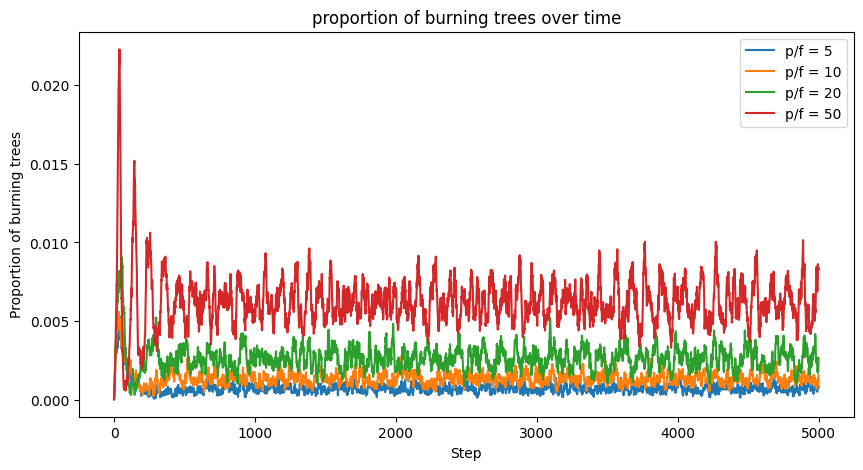

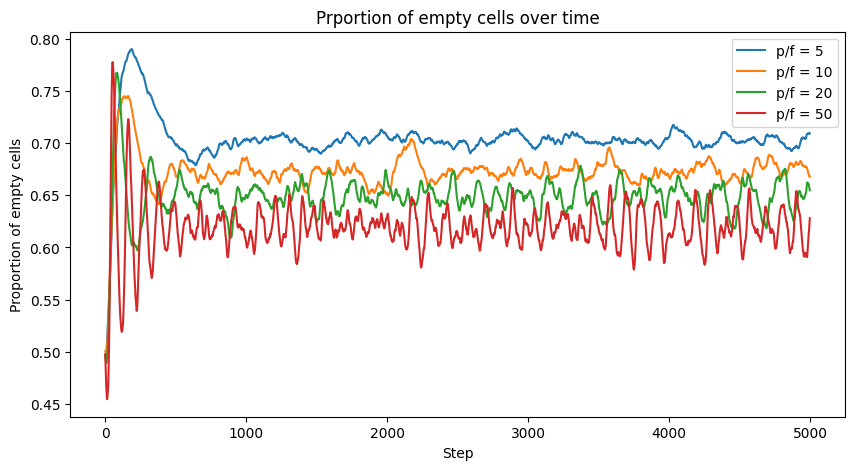

In [5]:
# Parameters for the simulations
width = height = 200
f_fixed = 0.0002
ratios = [5, 10, 20, 50]
n_steps = 5000

results_states = {}

# We test different p/f ratios by adjusting p while keeping f fixed
for ratio in ratios:
    p_value = ratio * f_fixed

    model = DrosselSchwablForestFire(
        width=width,
        height=height,
        p=p_value,
        f=f_fixed,
        initial_tree_density=0.5
    )

    model.ignite_random_tree()
    
    # We run the simulation and record the state counts over time
    trees_series, fires_series, empty_series = simulate_state_counts(model, n_steps=n_steps)

    results_states[ratio] = {
        "trees": trees_series,
        "fires": fires_series,
        "empty": empty_series
    }

    print(f"Simulaton over for theta = {ratio}")

total_cells = width * height

plt.figure(figsize=(10, 5))
for ratio in ratios:
    plt.plot(np.array(results_states[ratio]["trees"]) / total_cells, label=f"p/f = {ratio}")
plt.xlabel("Step")
plt.ylabel("¨Proportion of living trees")
plt.title("Proportion of living trees over time")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for ratio in ratios:
    plt.plot(np.array(results_states[ratio]["fires"]) / total_cells, label=f"p/f = {ratio}")
plt.xlabel("Step")
plt.ylabel("Proportion of burning trees")
plt.title("proportion of burning trees over time")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for ratio in ratios:
    plt.plot(np.array(results_states[ratio]["empty"]) / total_cells, label=f"p/f = {ratio}")
plt.xlabel("Step")
plt.ylabel("Proportion of empty cells")
plt.title("Prportion of empty cells over time")
plt.legend()
plt.show()

# Study of the density

Running p=5e-05, f=0.0001, p/f=0.5
Running p=0.0002, f=0.0001, p/f=2.0
Running p=0.0005, f=0.0001, p/f=5.0
Running p=0.001, f=0.0001, p/f=10.0
Running p=0.002, f=0.0001, p/f=20.0
Running p=0.005, f=0.0001, p/f=50.0
Running p=0.01, f=0.0001, p/f=100.0
Running p=0.02, f=0.0001, p/f=200.0
Running p=0.1, f=0.0001, p/f=1000.0


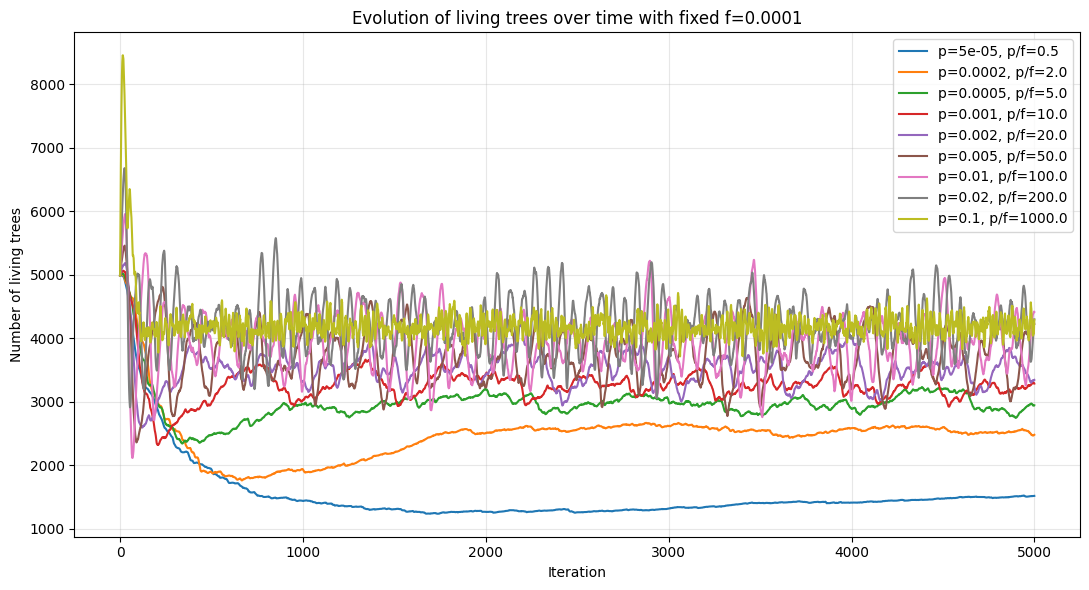

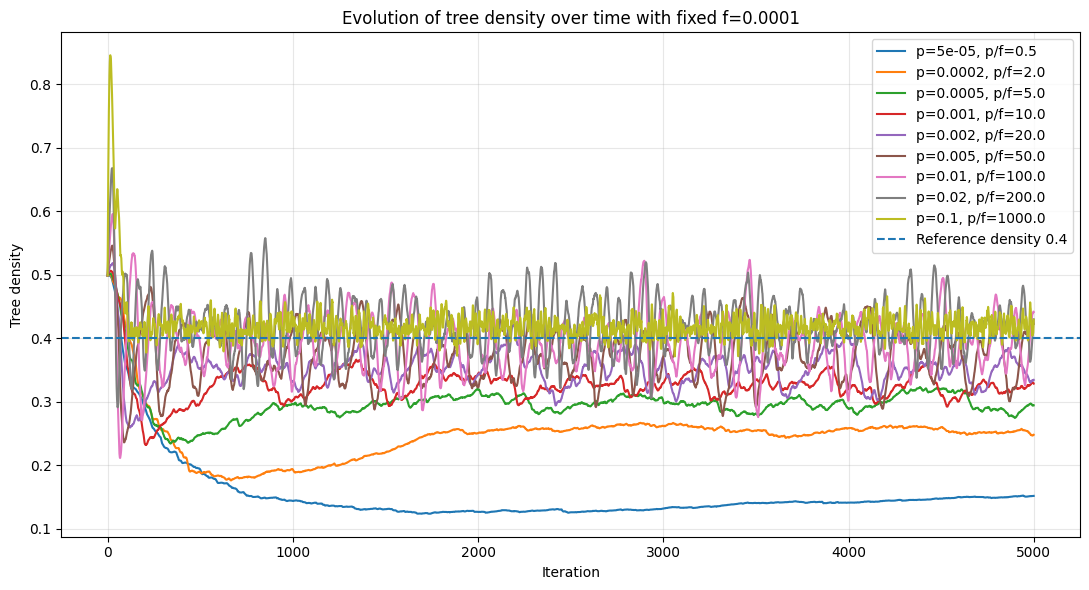

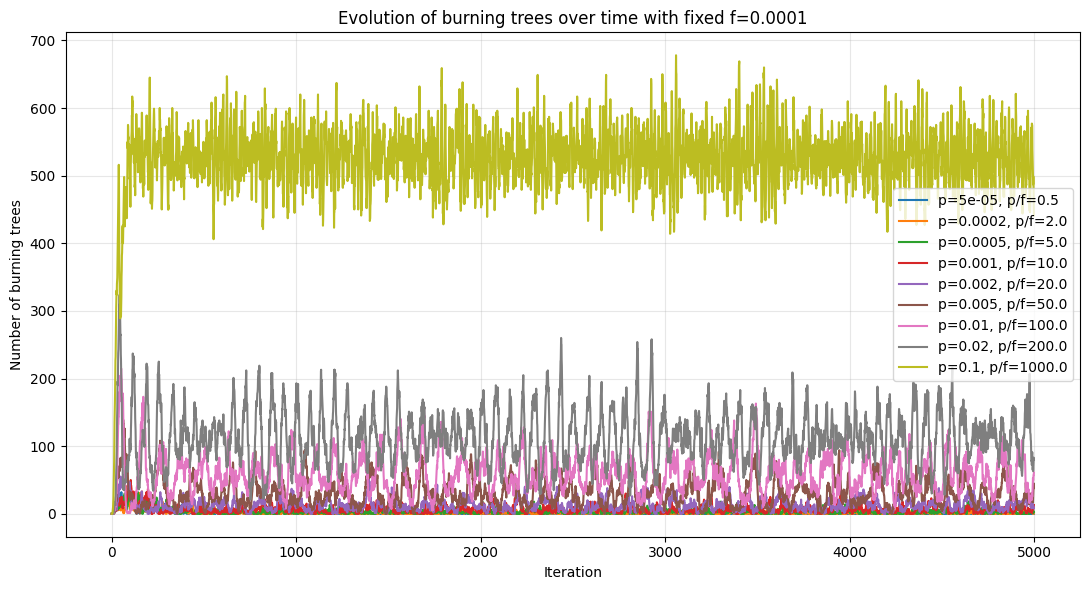

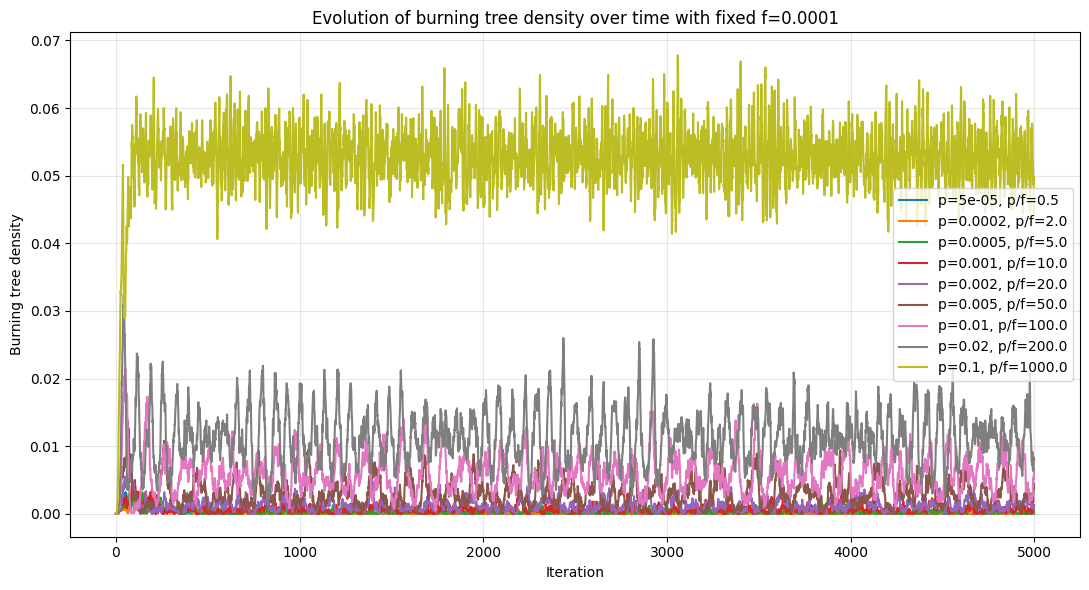


Summary statistics:
p=5e-05    | p/f=    0.5 | mean density=0.154 | min density=0.124 | max density=0.499 | std density=0.054 | mean burning density=0.000111 | max burning density=0.003
p=0.0002   | p/f=    2.0 | mean density=0.248 | min density=0.176 | max density=0.501 | std density=0.045 | mean burning density=0.000202 | max burning density=0.003
p=0.0005   | p/f=    5.0 | mean density=0.297 | min density=0.234 | max density=0.502 | std density=0.031 | mean burning density=0.000390 | max burning density=0.003
p=0.001    | p/f=   10.0 | mean density=0.327 | min density=0.232 | max density=0.507 | std density=0.030 | mean burning density=0.000705 | max burning density=0.005
p=0.002    | p/f=   20.0 | mean density=0.353 | min density=0.260 | max density=0.519 | std density=0.030 | mean burning density=0.001328 | max burning density=0.007
p=0.005    | p/f=   50.0 | mean density=0.377 | min density=0.236 | max density=0.546 | std density=0.044 | mean burning density=0.003124 | max burni

In [ ]:

def count_trees(model):
    """Count the number of living trees in the grid."""
    return sum(cell == model.TREE for row in model.grid for cell in row)


def count_burning_trees(model):
    """Count the number of burning trees in the grid."""
    return sum(cell == model.FIRE for row in model.grid for cell in row)


def run_tree_density_simulation(
    width,
    height,
    p,
    f,
    n_steps=10000,
    initial_tree_density=0.5,
    seed=42
):
    """
    Run one Drossel-Schwabl simulation and return:
    - number of living trees over time
    - living tree density over time
    - number of burning trees over time
    - burning tree density over time
    """
    random.seed(seed)
    np.random.seed(seed)

    model = DrosselSchwablForestFire(
        width=width,
        height=height,
        p=p,
        f=f,
        initial_tree_density=initial_tree_density
    )

    tree_counts = []
    tree_densities = []

    burning_counts = []
    burning_densities = []

    for _ in range(n_steps):
        n_trees = count_trees(model)
        n_burning = count_burning_trees(model)

        tree_counts.append(n_trees)
        tree_densities.append(n_trees / (width * height))

        burning_counts.append(n_burning)
        burning_densities.append(n_burning / (width * height))

        model.step()

    return (
        np.array(tree_counts),
        np.array(tree_densities),
        np.array(burning_counts),
        np.array(burning_densities)
    )


# Simulation settings
width = height = 100
n_steps = 5000
initial_tree_density = 0.5

# Fixed intermediate lightning probability
f_fixed = 0.0001

# Values of p to test
p_values = [
    0.00005,
    0.0002,
    0.0005,
    0.001,
    0.002,
    0.005,
    0.01,
    0.02,
    0.1
]

results = {}

for p in p_values:
    print(f"Running p={p}, f={f_fixed}, p/f={p / f_fixed:.1f}")

    tree_counts, densities, burning_counts, burning_densities = run_tree_density_simulation(
        width=width,
        height=height,
        p=p,
        f=f_fixed,
        n_steps=n_steps,
        initial_tree_density=initial_tree_density,
        seed=42
    )

    results[p] = {
        "tree_counts": tree_counts,
        "densities": densities,
        "burning_counts": burning_counts,
        "burning_densities": burning_densities,
        "ratio": p / f_fixed,
        "mean_density": np.mean(densities),
        "min_density": np.min(densities),
        "max_density": np.max(densities),
        "std_density": np.std(densities),
        "mean_burning_density": np.mean(burning_densities),
        "min_burning_density": np.min(burning_densities),
        "max_burning_density": np.max(burning_densities),
        "std_burning_density": np.std(burning_densities),
    }


# Plot number of living trees over time
plt.figure(figsize=(11, 6))

for p, res in results.items():
    plt.plot(
        res["tree_counts"],
        label=f"p={p}, p/f={res['ratio']:.1f}"
    )

plt.xlabel("Iteration")
plt.ylabel("Number of living trees")
plt.title(f"Evolution of living trees over time with fixed f={f_fixed}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Plot tree density over time
plt.figure(figsize=(11, 6))

for p, res in results.items():
    plt.plot(
        res["densities"],
        label=f"p={p}, p/f={res['ratio']:.1f}"
    )

plt.xlabel("Iteration")
plt.ylabel("Tree density")
plt.title(f"Evolution of tree density over time with fixed f={f_fixed}")
plt.axhline(0.4, linestyle="--", label="Reference density 0.4")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Plot number of burning trees over time
plt.figure(figsize=(11, 6))

for p, res in results.items():
    plt.plot(
        res["burning_counts"],
        label=f"p={p}, p/f={res['ratio']:.1f}"
    )

plt.xlabel("Iteration")
plt.ylabel("Number of burning trees")
plt.title(f"Evolution of burning trees over time with fixed f={f_fixed}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Plot burning tree density over time
plt.figure(figsize=(11, 6))

for p, res in results.items():
    plt.plot(
        res["burning_densities"],
        label=f"p={p}, p/f={res['ratio']:.1f}"
    )

plt.xlabel("Iteration")
plt.ylabel("Burning tree density")
plt.title(f"Evolution of burning tree density over time with fixed f={f_fixed}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Summary statistics
print("\nSummary statistics:")
for p, res in results.items():
    print(
        f"p={p:<8} | "
        f"p/f={res['ratio']:>7.1f} | "
        f"mean density={res['mean_density']:.3f} | "
        f"min density={res['min_density']:.3f} | "
        f"max density={res['max_density']:.3f} | "
        f"std density={res['std_density']:.3f} | "
        f"mean burning density={res['mean_burning_density']:.6f} | "
        f"max burning density={res['max_burning_density']:.3f}"
    )




# Simulation with the second implementation : DS-FFM

In [6]:

theta_values = [100, 300, 1000, 3000, 5000]

outputs = {}
fire_distributions = {}

for theta in theta_values:
    print(theta)

    model = DrosselSchwablFFM(
        L=128,
        theta=theta,
        fixed="f",
        f=0.00001,
        seed=42
    )

    results = model.run(
        steps=50000,
        burn_in=10000
    )

    fire_sizes = results["fire_sizes"]
    fire_sizes = fire_sizes[fire_sizes > 0]

    fire_distributions[theta] = fire_sizes.copy()

    outputs[theta] = {
        "mean_density": results["tree_density"].mean(),
        "mean_fire_size": fire_sizes.mean(),
        "max_fire_size": fire_sizes.max(),
        "n_fires": len(fire_sizes)
    }

for theta, stats in outputs.items():
    print(theta, stats)

100
300
1000
3000
5000
100 {'mean_density': np.float64(0.37815259704589843), 'mean_fire_size': np.float64(164.13393444780834), 'max_fire_size': np.int64(4446), 'n_fires': 15194}
300 {'mean_density': np.float64(0.3947391403198242), 'mean_fire_size': np.float64(465.1014529534928), 'max_fire_size': np.int64(7792), 'n_fires': 15761}
1000 {'mean_density': np.float64(0.41936419982910156), 'mean_fire_size': np.float64(1427.0051245381958), 'max_fire_size': np.int64(12209), 'n_fires': 16782}
3000 {'mean_density': np.float64(0.4664383087158203), 'mean_fire_size': np.float64(3758.7262904519926), 'max_fire_size': np.int64(14254), 'n_fires': 18695}
5000 {'mean_density': np.float64(0.5159482406616211), 'mean_fire_size': np.float64(5521.7118189356615), 'max_fire_size': np.int64(15107), 'n_fires': 20501}


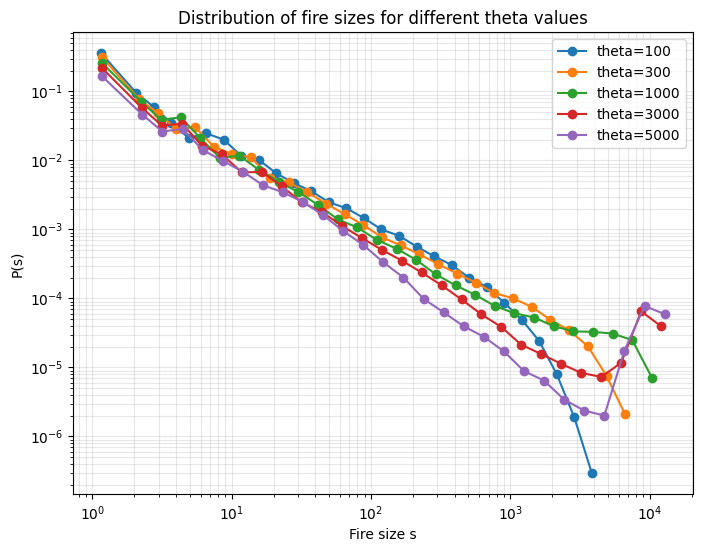

In [7]:
plt.figure(figsize=(8, 6))

for theta in theta_values:
    data = fire_distributions[theta]

    if len(data) == 0:
        continue

    bins = np.logspace(np.log10(1), np.log10(data.max()), 30)
    hist, edges = np.histogram(data, bins=bins, density=True)

    # bins centers for plotting
    centers = np.sqrt(edges[:-1] * edges[1:])

    mask = hist > 0
    plt.plot(centers[mask], hist[mask], marker="o", linestyle="-", label=f"theta={theta}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Fire size s")
plt.ylabel("P(s)")
plt.title("Distribution of fire sizes for different theta values")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()